In [17]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/interim/cars_cleaned.csv")

In [2]:
df

,name,city,price,model,kilometer,fuel_type,engine,transmission,brand
0,Honda Civic 1.5 RS Turbo,abbottabad,6700000.0,2021,88000,petrol,1500,automatic,honda
1,Honda Civic Oriel 1.8 i-VTEC CVT,peshawar,6150000.0,2019,68425,petrol,1800,automatic,honda
2,Toyota Hilux D-4D Automatic,peshawar,6550000.0,2012,132000,diesel,3000,automatic,toyota
3,Toyota Prius Alpha S Touring Selection GR Sport,peshawar,9850000.0,2018,35000,hybrid,1800,automatic,toyota
4,Toyota Corolla Fielder Hybrid G WB,peshawar,6200000.0,2017,165044,hybrid,1500,automatic,toyota
...,...,...,...,...,...,...,...,...,...
4670,Suzuki Cultus VXR (CNG),mardan,1190000.0,2007,80000,petrol,1000,manual,suzuki
4671,Suzuki Alto,peshawar,1270000.0,1998,120000,petrol,660,automatic,suzuki
4672,Suzuki Mehran VX,charsadda,550000.0,2004,100000,petrol,800,manual,suzuki
4673,Suzuki Alto VXR,peshawar,1499000.0,2011,95000,petrol,1000,manual,suzuki


In [4]:
print("\nTail:\n", df.tail())


Tail:
                           name       city      price  model  kilometer  \
4670   Suzuki Cultus VXR (CNG)     mardan  1190000.0   2007      80000   
4671               Suzuki Alto   peshawar  1270000.0   1998     120000   
4672          Suzuki Mehran VX  charsadda   550000.0   2004     100000   
4673           Suzuki Alto VXR   peshawar  1499000.0   2011      95000   
4674  Toyota Corolla GL Saloon  charsadda   880000.0   1986     200000   

     fuel_type  engine transmission   brand  
4670    petrol    1000       manual  suzuki  
4671    petrol     660    automatic  suzuki  
4672    petrol     800       manual  suzuki  
4673    petrol    1000       manual  suzuki  
4674       cng    1500       manual  toyota  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4675 entries, 0 to 4674
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          4675 non-null   str    
 1   city          4675 non-null   str    
 2   price         4674 non-null   float64
 3   model         4675 non-null   int64  
 4   kilometer     4675 non-null   int64  
 5   fuel_type     4675 non-null   str    
 6   engine        4675 non-null   int64  
 7   transmission  4675 non-null   str    
 8   brand         4675 non-null   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 328.8 KB


In [5]:
print("\nMissing Values (%):")
print(df.isnull().mean() * 100)


Missing Values (%):
name            0.00000
city            0.00000
price           0.02139
model           0.00000
kilometer       0.00000
fuel_type       0.00000
engine          0.00000
transmission    0.00000
brand           0.00000
dtype: float64


In [6]:
df.dropna(inplace=True)

In [9]:
print("\nMissing Values (%):")
print(df.isnull().mean() * 100)


Missing Values (%):
name            0.0
city            0.0
price           0.0
model           0.0
kilometer       0.0
fuel_type       0.0
engine          0.0
transmission    0.0
brand           0.0
dtype: float64


In [7]:
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [8]:
print("\nNumerical Summary:\n", df.describe())


Numerical Summary:
               price        model       kilometer        engine
count  4.674000e+03  4674.000000     4674.000000   4674.000000
mean   2.737681e+06  2009.029953   126679.121523   1334.633718
std    1.984925e+06    10.146011   112481.998404    621.461484
min    1.010000e+05  1949.000000        1.000000    160.000000
25%    1.200000e+06  2004.000000    56579.000000   1000.000000
50%    2.250000e+06  2010.000000   105000.000000   1300.000000
75%    3.800000e+06  2017.000000   166000.000000   1500.000000
max    9.900000e+06  2026.000000  1000000.000000  12000.000000


# Numerical Summary

Price:
Range: 101,000 → 9,900,000 PKR
Mean: ~2.73M | Median: ~2.25M
Insight: Mean > median ⇒ right-skewed (few very expensive cars pulling average up)

Model:
Range: 1949 → 2026
Median: 2010
Insight: Wide spread; includes very old + very new cars

Action:

Consider age feature:

 Kilometer
Range: 1 → 1,000,000 (!!)
Median: 105,000
Insight: Heavy spread + extreme outliers

Engine (CC)
Range: 160 → 12,000
Median: 1300
Insight: Most cars are 1000–1500cc, but extreme values exist

In [10]:
# 6. UNIQUE VALUES
# -----------------------------
categorical_cols = ["city", "fuel_type", "transmission", "brand"]

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())


city unique values:
city
peshawar            2106
abbottabad           618
mardan               413
mansehra             280
haripur              227
swabi                219
nowshera             131
charsadda            116
dera ismail khan     114
kohat                109
nowshera cantt        45
bannu                 45
karak                 28
swat                  28
risalpur              21
malakand agency       19
takhtbai              17
swatmingora           16
lower dir             14
topi                  13
akora khattak         12
bat khela             12
buner                 11
mingora                8
lakki marwat           7
ghazi                  6
hawilian               5
darya khan             5
hayatabad              5
dargai                 4
qalandarabad           4
jehangira              3
dir                    3
balakot                3
hattar                 2
gohar ghoushti         1
jamrud road            1
tank                   1
saidu sharif           1

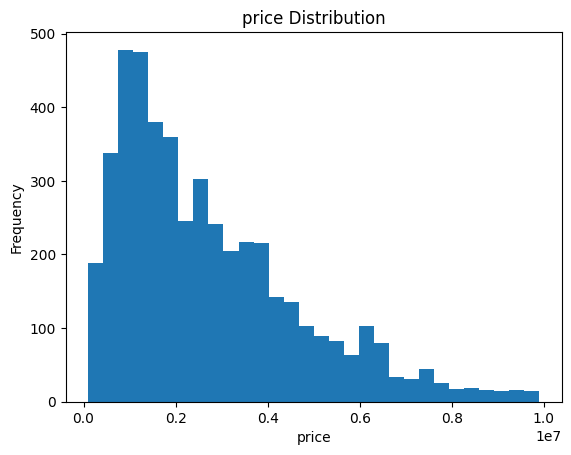

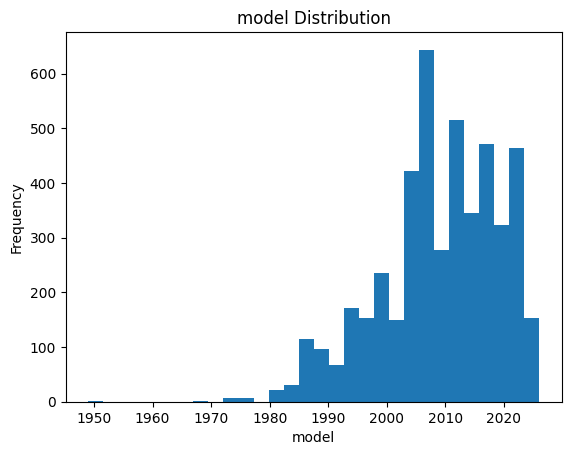

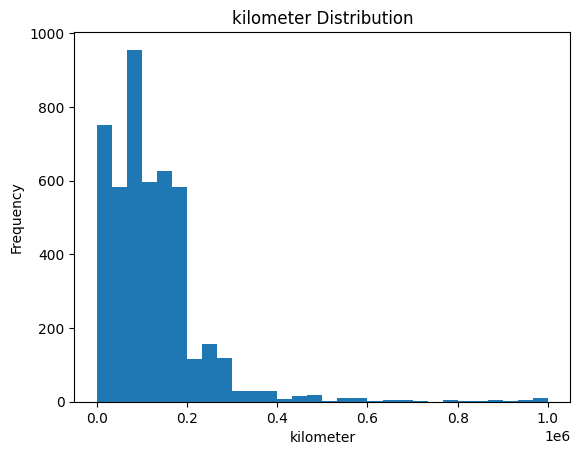

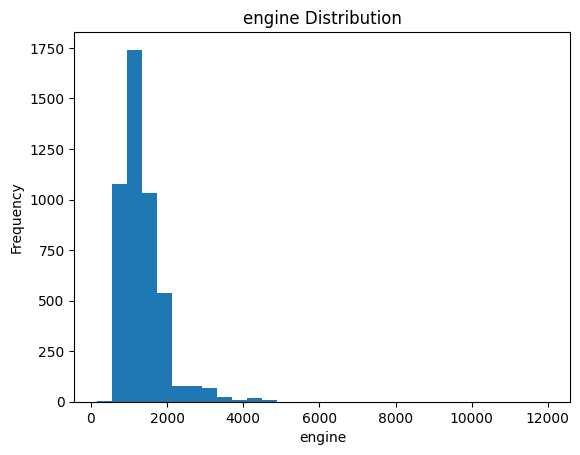

In [18]:
num_cols = ["price", "model", "kilometer", "engine"]

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


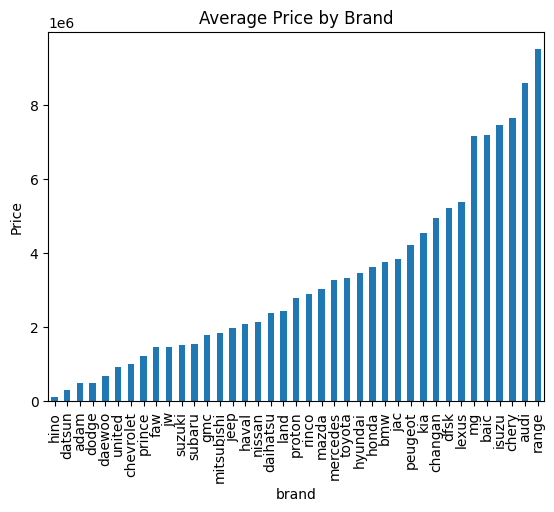

In [19]:
# -----------------------------
# Price by brand
plt.figure()
df.groupby("brand")["price"].mean().sort_values().plot(kind='bar')
plt.title("Average Price by Brand")
plt.ylabel("Price")
plt.show()

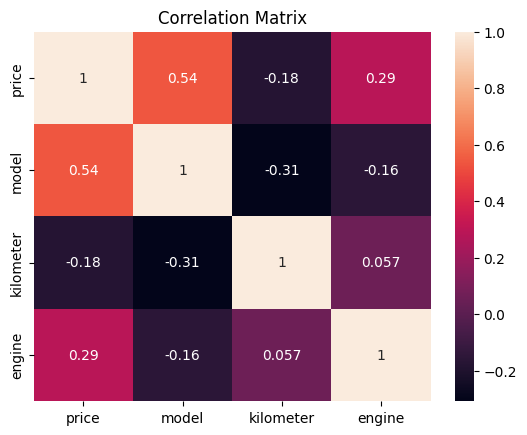

In [ ]:
# . CORRELATION
# -----------------------------
plt.figure()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

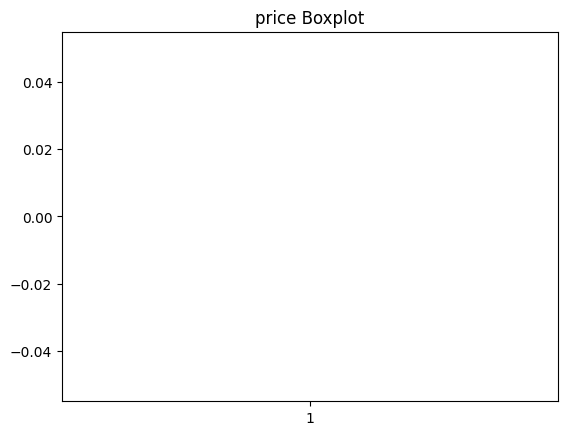

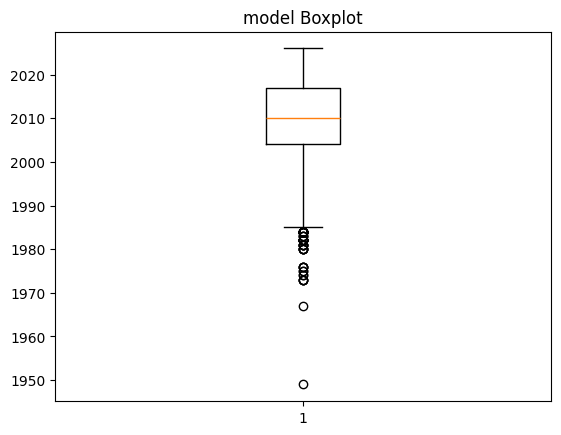

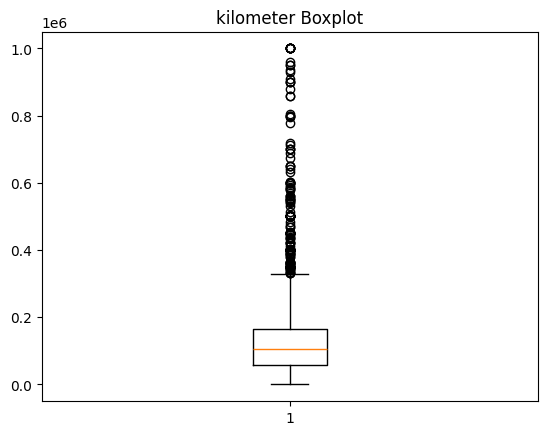

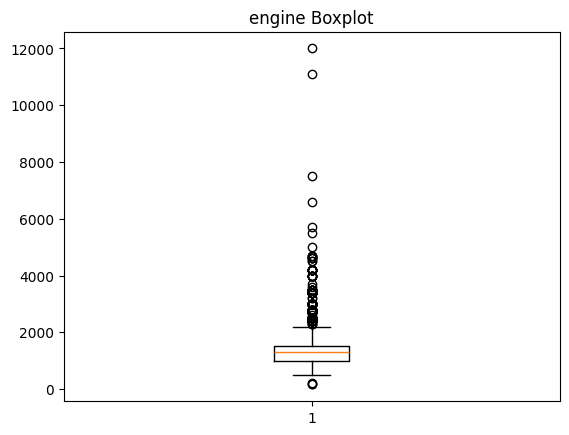

In [ ]:
# . OUTLIER DETECTION
# -----------------------------
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

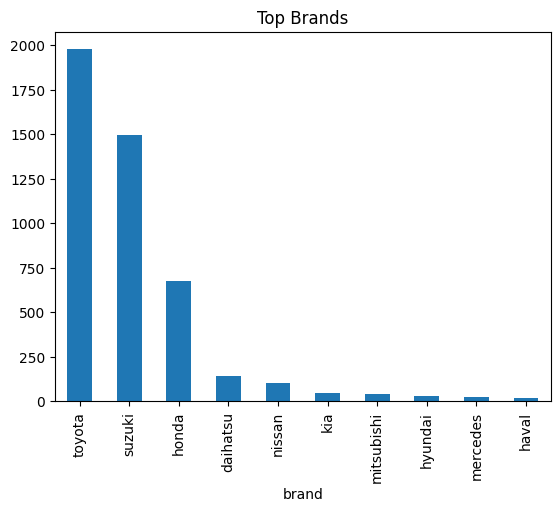

In [ ]:
# -----------------------------
# . TOP BRANDS
# -----------------------------
plt.figure()
df["brand"].value_counts().head(10).plot(kind='bar')
plt.title("Top Brands")
plt.show()